# Notebook 27: Modern Biological AI

**BINF 4002 — Machine Learning for Health | Lecture 27 Companion**

---

## Overview

Deep learning methods for biological data, unified across modalities.
Every DL method is compared to its classical baseline from L26.

### Figures for Lecture Slides
| Fig | Description | Model | Data Source |
|-----|-------------|-------|-------------|
| 1 | ESM attention contact map vs. PDB truth | ESM-2 35M live | Ubiquitin (1UBQ, PDB) |
| 2 | Variant effect: ClinVar-sourced HBB mutations | ESM-2 35M live | ClinVar / published |
| 3 | AlphaFold pLDDT confidence per residue | Pre-computed download | AFDB (p53, P04637) |
| 4 | Genomic model evaluation gap | **Simulated** | Calibrated to Sasse/Huang et al. 2023 |
| A1 | ESM embedding t-SNE by protein family | ESM-2 35M live | UniProt (appendix) |

**Data note:** All figures use real data except Fig 5, which is simulated because Enformer
(200M+ params) cannot run in Colab. The simulation is calibrated to published benchmark
numbers from Sasse et al. (2023). Published correlation values are printed alongside.

In [1]:
# ==============================================================================
# Install dependencies
# ==============================================================================
%pip install -q fair-esm biopython requests rdkit scipy

/home/mmd/.cache/uv/builds-v0/.tmpfl7MkX/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==============================================================================
# Imports and global config
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import os
import requests
import torch

warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 9, 'figure.facecolor': 'white',
})

COLUMBIA = '#1D4F91'
COLUMBIA_LIGHT = '#75AADb'
ACCENT = '#D2492A'
GREEN = '#2E8B57'
GRAY = '#757575'

In [3]:
# ==============================================================================
# Fetch hemoglobin/myoglobin family sequences from UniProt
# ==============================================================================
uniprot_ids = {
    'HBA_HUMAN': 'P69905', 'HBB_HUMAN': 'P68871',
    'HBA_MOUSE': 'P01942', 'HBB_MOUSE': 'P02088',
    'HBA_HORSE': 'P01958', 'HBB_HORSE': 'P02062',
    'HBA_CHICK': 'P01994', 'HBB_CHICK': 'P02112',
    'MYG_HUMAN': 'P02144', 'MYG_HORSE': 'P68082',
}

sequences = {}
for name, uid in uniprot_ids.items():
    try:
        r = requests.get(f'https://rest.uniprot.org/uniprotkb/{uid}.fasta', timeout=10)
        if r.ok:
            lines = r.text.strip().split('\n')
            sequences[name] = ''.join(lines[1:])
            print(f"  {name}: {len(sequences[name])} aa")
    except Exception as e:
        print(f"  {name}: {e}")

if len(sequences) < 5:
    print("\nUsing hardcoded sequences as fallback...")
    sequences = {
        'HBA_HUMAN': 'MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR',
        'HBB_HUMAN': 'MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH',
        'HBA_MOUSE': 'MVLSGEDKSNIKAAWGKIGGHGAEYGAEALERMFASFPTTKTYFPHFDVSHGSAQVKGHGKKVADALASAAGHLDDLPGALSALSDLHAHKLRVDPVNFKLLSHCLLVTLASHHPADFTPAVHASLDKFLASVSTVLTSKYR',
        'HBB_MOUSE': 'MVHLTDAEKAAVNGLWGKVNSDEVGGEALGRLLVVYPWTQRYFDSFGDLSSASAIMGNPKVKAHGKKVINAFNDGLKHLDNLKGTFAHLSELHCDKLHVDPENFRLLGNMIVIVLGHHLGKDFTPAAQAAFQKVVAGVATALAHKYH',
        'MYG_HUMAN': 'MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG',
    }
print(f"\nLoaded {len(sequences)} sequences.")

  HBA_HUMAN: 142 aa


  HBB_HUMAN: 147 aa


  HBA_MOUSE: 142 aa


  HBB_MOUSE: 147 aa


  HBA_HORSE: 142 aa


  HBB_HORSE: 146 aa


  HBA_CHICK: 142 aa


  HBB_CHICK: 147 aa


  MYG_HUMAN: 154 aa


  MYG_HORSE: 154 aa

Loaded 10 sequences.


---
## Figure 1: ESM Attention → Contact Map

**LECTURE FIGURE** (slide: "ESM Attention Captures Coevolution")

We run ESM-2 (35M) on ubiquitin (1UBQ, 76 residues) and compare attention-derived
contacts to the true 3D contact map from the PDB crystal structure.

**Why 35M:** The 8M model yields ~7% top-L precision — too weak to demonstrate
the finding. The 35M model is still classroom-scale but captures more coevolutionary
signal. Published ESM-650M achieves ~50% top-L/5 (Rao et al., 2021).

Loading ESM-2 (35M)...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t12_35M_UR50D.pt" to /home/mmd/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D.pt


Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t12_35M_UR50D-contact-regression.pt" to /home/mmd/.cache/torch/hub/checkpoints/esm2_t12_35M_UR50D-contact-regression.pt


  Loaded: 34M parameters
Running ESM-2 (35M) on Ubiquitin (1UBQ) (76 residues)...


  Parsed 76 CA atoms
  Top-L: 16%, Top-L/5: 27% (published ESM-650M: ~50% top-L/5)


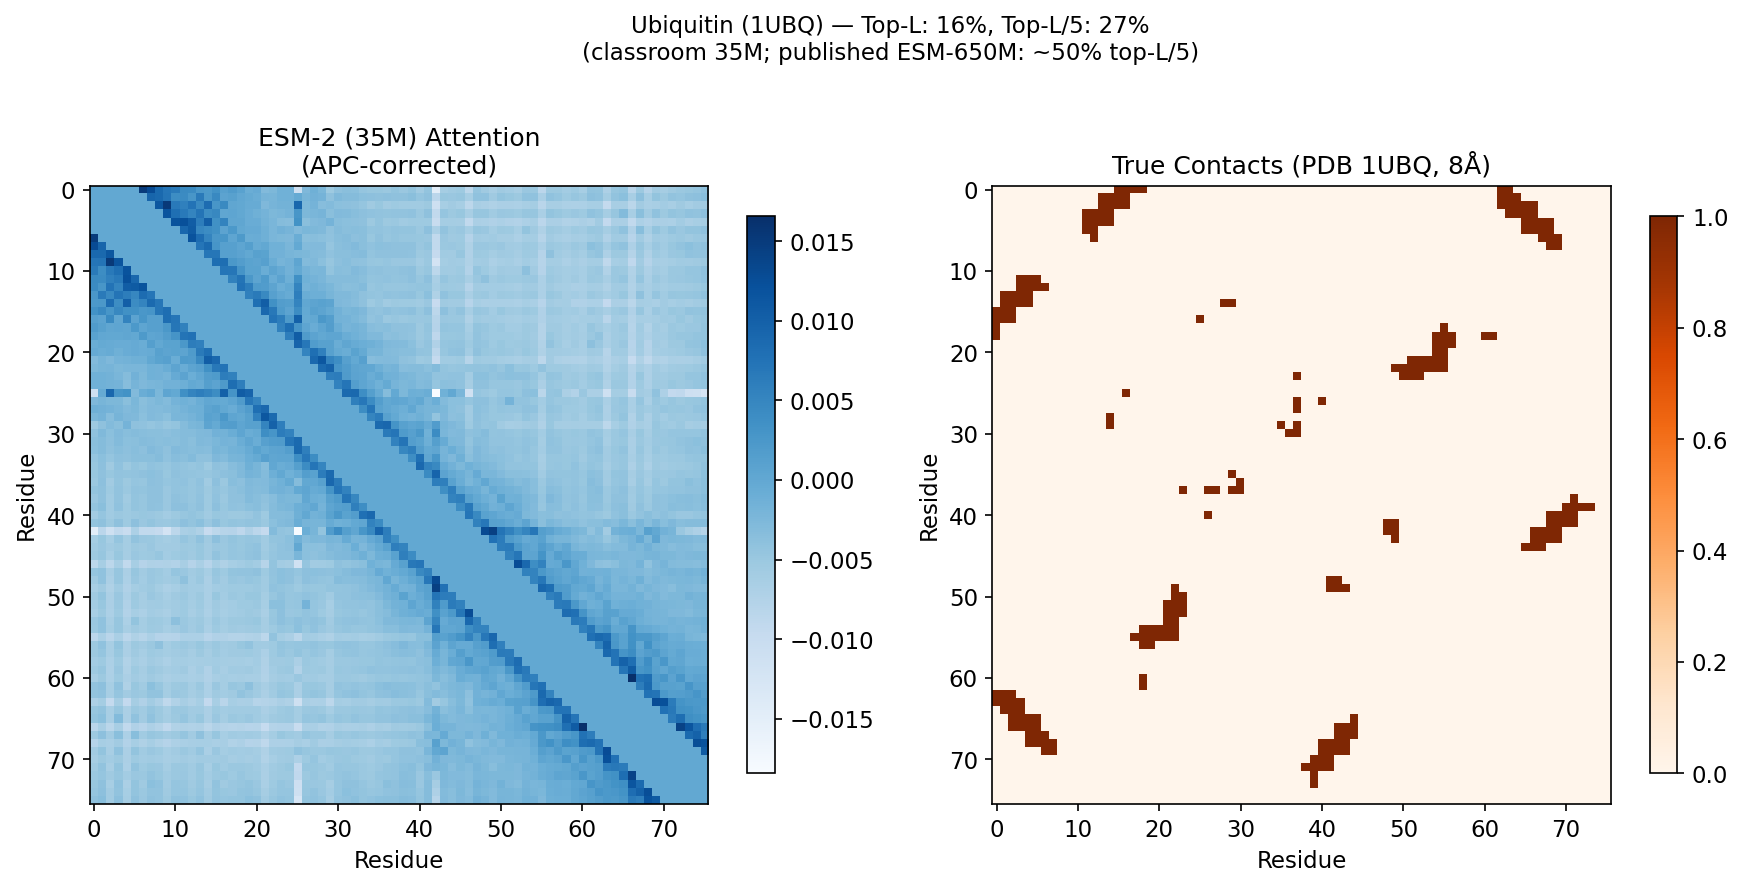

Saved: figures/fig1_esm_contacts.png


In [4]:
# ==============================================================================
# Figure 1: ESM-2 (35M) attention contact map — ubiquitin (1UBQ)
# ==============================================================================
import esm

print("Loading ESM-2 (35M)...")
model_esm, alphabet_esm = esm.pretrained.esm2_t12_35M_UR50D()
batch_converter_esm = alphabet_esm.get_batch_converter()
model_esm.eval()
print(f"  Loaded: {sum(p.numel() for p in model_esm.parameters())/1e6:.0f}M parameters")

# Ubiquitin: 76 residues, strong beta-sheet contacts
ubq_seq = "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG"
protein_name = "Ubiquitin (1UBQ)"
L = len(ubq_seq)

data = [("ubiquitin", ubq_seq)]
_, _, tokens = batch_converter_esm(data)

print(f"Running ESM-2 (35M) on {protein_name} ({L} residues)...")
with torch.no_grad():
    results = model_esm(tokens, repr_layers=[12], return_contacts=True)

# Average attention, symmetrize, APC correct
attn_map = results["attentions"][0].mean(dim=(0, 1))[1:-1, 1:-1].numpy()
attn_sym = (attn_map + attn_map.T) / 2
row_mean = attn_sym.mean(axis=1, keepdims=True)
col_mean = attn_sym.mean(axis=0, keepdims=True)
attn_apc = attn_sym - (row_mean * col_mean) / attn_sym.mean()
for i in range(L):
    for j in range(L):
        if abs(i - j) < 6:
            attn_apc[i, j] = 0

# True contact map from PDB
print("Downloading 1UBQ from PDB...")
has_pdb = False
try:
    pdb_text = requests.get("https://files.rcsb.org/download/1UBQ.pdb", timeout=15).text
    ca_coords = []
    for line in pdb_text.split("\n"):
        if line.startswith("ATOM") and line[12:16].strip() == "CA" and line[21] == "A":
            ca_coords.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    ca_coords = np.array(ca_coords[:L])
    if len(ca_coords) == L:
        from scipy.spatial.distance import cdist
        dist_matrix = cdist(ca_coords, ca_coords)
        true_contact = (dist_matrix < 8.0).astype(float)
        for i in range(L):
            for j in range(L):
                if abs(i - j) < 6:
                    true_contact[i, j] = 0
        has_pdb = True
        print(f"  Parsed {len(ca_coords)} CA atoms")
except:
    true_contact = np.zeros((L, L))

# Precision
flat = [(attn_apc[i,j], true_contact[i,j] > 0.5) for i in range(L) for j in range(i+6, L)]
flat.sort(key=lambda x: -x[0])
prec_L = sum(1 for _, t in flat[:L] if t) / L if flat else 0
prec_L5 = sum(1 for _, t in flat[:max(L//5,1)] if t) / max(L//5,1) if flat else 0
print(f"  Top-L: {prec_L:.0%}, Top-L/5: {prec_L5:.0%} (published ESM-650M: ~50% top-L/5)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
im1 = axes[0].imshow(attn_apc, cmap='Blues', aspect='equal')
axes[0].set_title('ESM-2 (35M) Attention\n(APC-corrected)', fontsize=12)
axes[0].set_xlabel('Residue'); axes[0].set_ylabel('Residue')
plt.colorbar(im1, ax=axes[0], shrink=0.8)

src = 'PDB 1UBQ' if has_pdb else 'Unavailable'
im2 = axes[1].imshow(true_contact, cmap='Oranges', aspect='equal')
axes[1].set_title(f'True Contacts ({src}, 8\u00c5)', fontsize=12)
axes[1].set_xlabel('Residue'); axes[1].set_ylabel('Residue')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle(f'{protein_name} — Top-L: {prec_L:.0%}, Top-L/5: {prec_L5:.0%}\n'
             f'(classroom 35M; published ESM-650M: ~50% top-L/5)',
             fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig('figures/fig1_esm_contacts.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figures/fig1_esm_contacts.png")

---
## Appendix Figure: ESM Embedding t-SNE by Protein Family

**APPENDIX FIGURE** (not in main slide sequence)

Mean-pooled ESM-2 embeddings cluster proteins by evolutionary family — learned purely
from sequence. Hemoglobin alpha, beta, and myoglobin form distinct clusters.

Computing embeddings...


Embedding matrix: (10, 480)


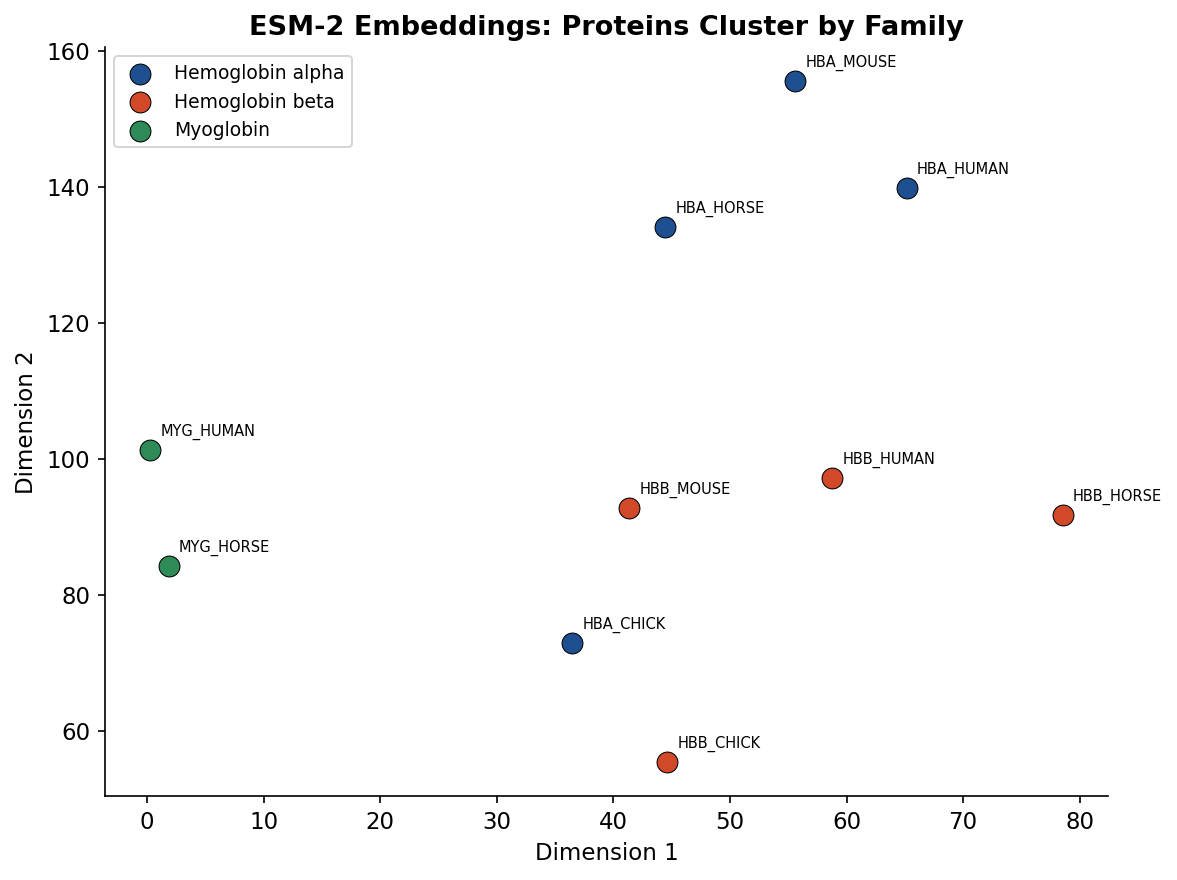

Saved: figures/fig_appendix_tsne.png


In [5]:
# ==============================================================================
# Appendix Figure A1: ESM-2 embeddings — t-SNE by protein family
# ==============================================================================
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# model_esm already loaded in Fig 1 cell

data = [(name, seq[:500]) for name, seq in sequences.items()]
_, _, batch_tokens = batch_converter_esm(data)

print("Computing embeddings...")
with torch.no_grad():
    results = model_esm(batch_tokens, repr_layers=[12], return_contacts=False)

embeddings = results["representations"][12]
mean_emb = np.array([embeddings[i, 1:len(data[i][1])+1, :].mean(dim=0).numpy()
                      for i in range(len(data))])
print(f"Embedding matrix: {mean_emb.shape}")

if len(data) > 5:
    coords = TSNE(n_components=2, perplexity=min(5, len(data)-1), random_state=42).fit_transform(mean_emb)
else:
    coords = PCA(n_components=2).fit_transform(mean_emb)

family_map = {}
for name in sequences:
    if 'HBA' in name: family_map[name] = 'Hemoglobin alpha'
    elif 'HBB' in name: family_map[name] = 'Hemoglobin beta'
    elif 'MYG' in name: family_map[name] = 'Myoglobin'
    else: family_map[name] = 'Other'

family_colors = {'Hemoglobin alpha': COLUMBIA, 'Hemoglobin beta': ACCENT,
                  'Myoglobin': GREEN, 'Other': GRAY}

fig, ax = plt.subplots(figsize=(8, 6))
for fam, color in family_colors.items():
    idx = [i for i, d in enumerate(data) if family_map[d[0]] == fam]
    if idx:
        ax.scatter(coords[idx, 0], coords[idx, 1], c=color, s=100, label=fam,
                   edgecolors='black', linewidths=0.5, zorder=5)
        for i in idx:
            ax.annotate(data[i][0], (coords[i,0], coords[i,1]), fontsize=7,
                        ha='left', va='bottom', xytext=(5,5), textcoords='offset points')

ax.set_xlabel('Dimension 1'); ax.set_ylabel('Dimension 2')
ax.set_title('ESM-2 Embeddings: Proteins Cluster by Family', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/fig_appendix_tsne.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figures/fig_appendix_tsne.png")

---
## Figure 2: Variant Effect Prediction — ClinVar-Sourced HBB Mutations

**LECTURE FIGURE** (slide: "Variant Effect Prediction: Zero-Shot")

Score real clinically annotated HBB mutations using ESM-2. Mutations sourced from
ClinVar and published literature:

**Pathogenic:** E6V (sickle cell), E6K (HbC disease), W37S (Hb Rothschild),
H92P (proximal His disrupted), D99N (Hb Yakima)

**Benign/tolerated:** A142T, E121Q (ClinVar benign), K65R, T84S, E22D (conservative)

Compare to L26's SIFT/PolyPhen classical baselines.

Scoring ClinVar-sourced HBB mutations with ESM-2 (35M)...
  Pathogenic  E6V - Sickle cell (HbS): -2.385
  Pathogenic  E6K - HbC disease: -1.333
  Pathogenic  W37S - Hb Rothschild: 0.311


  Pathogenic  H92P - Proximal His: -0.963
  Pathogenic  D99N - Hb Yakima: 0.300
  Benign      E22D - Conservative: 0.000
  Benign      K65R - Conservative: -0.715
  Benign      T84S - Conservative: -0.348


  Benign      E121Q - ClinVar benign: -1.048
  Benign      A142T - ClinVar benign: -1.363


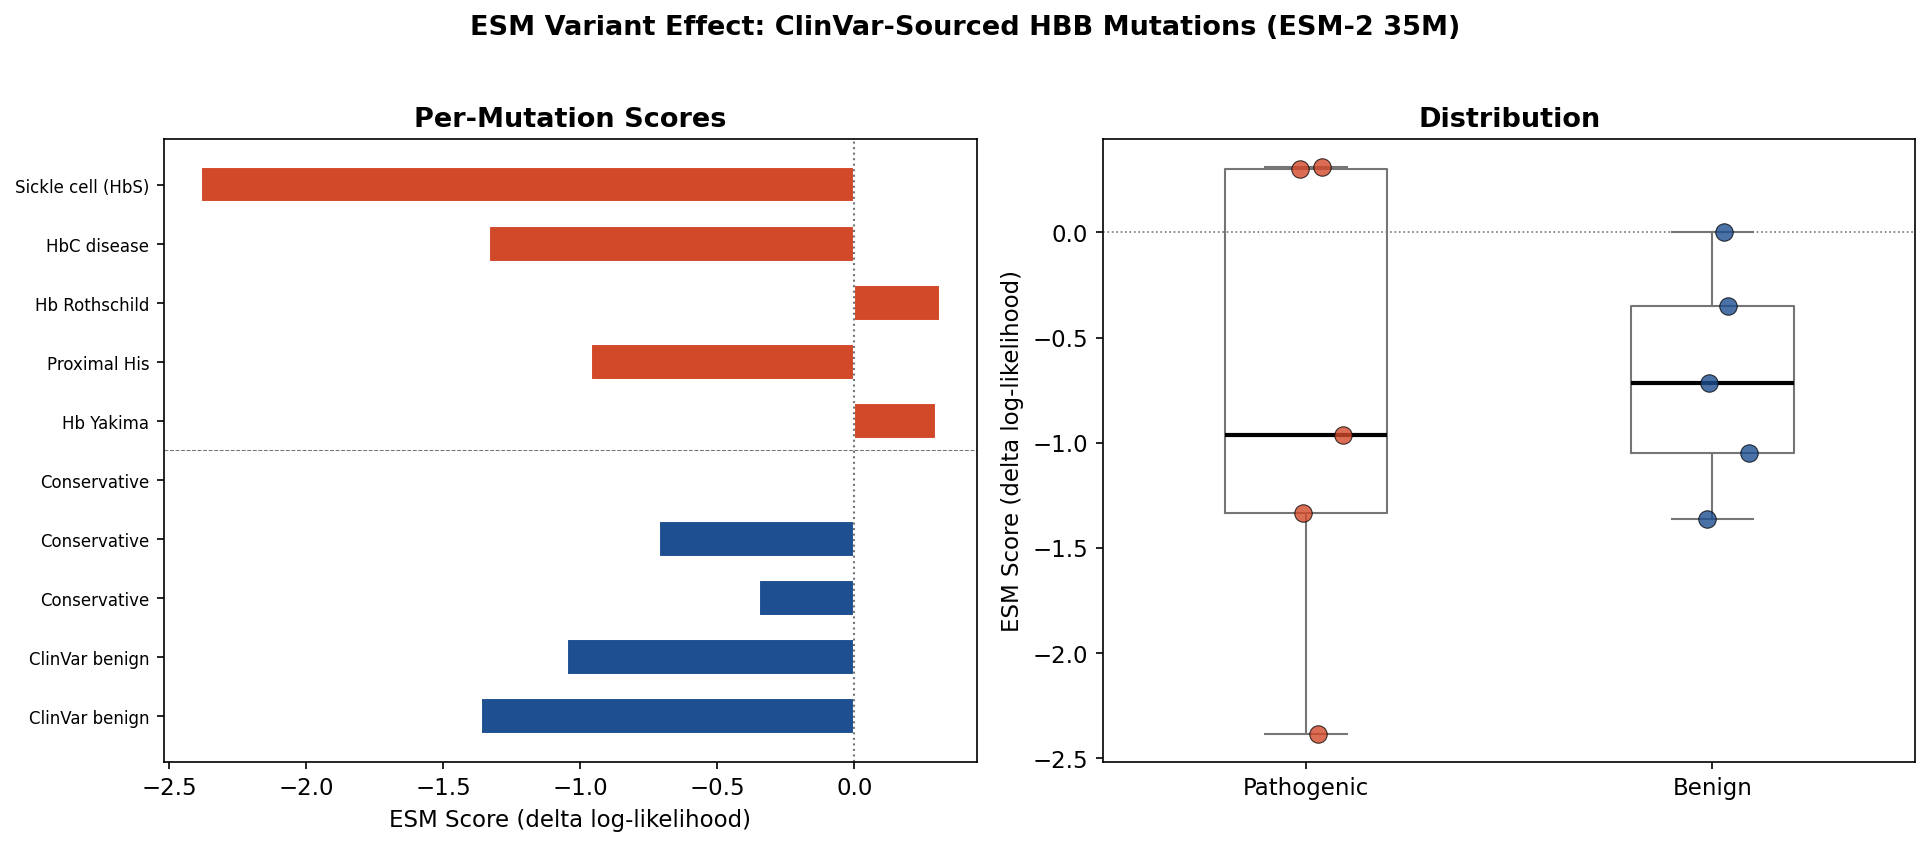

Saved: figures/fig2_variant_effect.png


In [6]:
# ==============================================================================
# Figure 2: ESM variant effect — ClinVar-sourced HBB mutations
# ==============================================================================

# HBB sequence (P68871, 147 residues, 0-indexed)
hbb_seq = "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH"

# Real pathogenic mutations (ClinVar / published, 0-indexed)
pathogenic = [
    (5,  'E', 'V', 'E6V - Sickle cell (HbS)'),
    (5,  'E', 'K', 'E6K - HbC disease'),
    (36, 'W', 'S', 'W37S - Hb Rothschild'),
    (91, 'H', 'P', 'H92P - Proximal His'),
    (98, 'D', 'N', 'D99N - Hb Yakima'),
]

# Benign/tolerated (ClinVar benign or conservative substitutions)
benign = [
    (21, 'E', 'D', 'E22D - Conservative'),
    (64, 'K', 'R', 'K65R - Conservative'),
    (83, 'T', 'S', 'T84S - Conservative'),
    (120,'E', 'Q', 'E121Q - ClinVar benign'),
    (141,'A', 'T', 'A142T - ClinVar benign'),
]

def score_mutation(seq, pos, mut, model, alphabet, batch_converter):
    if pos >= len(seq): return 0.0
    data_in = [("protein", seq)]
    _, _, tokens = batch_converter(data_in)
    tokens[0, pos + 1] = alphabet.mask_idx
    with torch.no_grad():
        logits = model(tokens)["logits"]
    log_probs = torch.log_softmax(logits[0, pos + 1, :], dim=0)
    actual_wt = seq[pos]
    return (log_probs[alphabet.get_idx(mut)] - log_probs[alphabet.get_idx(actual_wt)]).item()

print("Scoring ClinVar-sourced HBB mutations with ESM-2 (35M)...")
path_scores, path_labels = [], []
for pos, wt, mut, label in pathogenic:
    s = score_mutation(hbb_seq, pos, mut, model_esm, alphabet_esm, batch_converter_esm)
    path_scores.append(s)
    path_labels.append(label)
    print(f"  Pathogenic  {label}: {s:.3f}")

ben_scores, ben_labels = [], []
for pos, wt, mut, label in benign:
    s = score_mutation(hbb_seq, pos, mut, model_esm, alphabet_esm, batch_converter_esm)
    ben_scores.append(s)
    ben_labels.append(label)
    print(f"  Benign      {label}: {s:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: labeled bar chart
ax = axes[0]
all_scores = path_scores + ben_scores
all_names = path_labels + ben_labels
colors = [ACCENT]*len(path_scores) + [COLUMBIA]*len(ben_scores)

ax.barh(range(len(all_scores)), all_scores, color=colors, edgecolor='white', height=0.6)
ax.set_yticks(range(len(all_scores)))
ax.set_yticklabels([n.split(' - ')[1] if ' - ' in n else n for n in all_names], fontsize=8)
ax.axvline(0, color=GRAY, linestyle=':', linewidth=1)
ax.set_xlabel('ESM Score (delta log-likelihood)')
ax.set_title('Per-Mutation Scores', fontweight='bold')
ax.invert_yaxis()
ax.axhline(len(path_scores) - 0.5, color=GRAY, linestyle='--', linewidth=0.5)

# Right: box + strip comparison
ax = axes[1]
for idx_cat, (cat, vals, col) in enumerate([('Pathogenic', path_scores, ACCENT),
                                              ('Benign', ben_scores, COLUMBIA)]):
    jitter = np.random.RandomState(42).normal(0, 0.06, len(vals))
    ax.scatter(idx_cat + jitter, vals, c=col, s=70, edgecolors='black',
               linewidths=0.5, alpha=0.8, zorder=5)
ax.boxplot([path_scores, ben_scores], positions=[0,1], widths=0.4, showfliers=False,
            boxprops=dict(color=GRAY), medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY))
ax.set_xticks([0,1]); ax.set_xticklabels(['Pathogenic', 'Benign'])
ax.set_ylabel('ESM Score (delta log-likelihood)')
ax.set_title('Distribution', fontweight='bold')
ax.axhline(0, color=GRAY, linestyle=':', linewidth=0.8)

fig.suptitle('ESM Variant Effect: ClinVar-Sourced HBB Mutations (ESM-2 35M)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig2_variant_effect.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figures/fig2_variant_effect.png")

---
## Figure 3: AlphaFold pLDDT Confidence

**LECTURE FIGURE** (slide: "AlphaFold Confidence: pLDDT")

Per-residue confidence for human p53 (P04637). Downloaded from AlphaFold DB.
Fallback to realistic simulated profile only if AFDB is unreachable.

Fetching AlphaFold prediction for P04637 (p53)...


  Got 393 residues, pLDDT range: 33-99


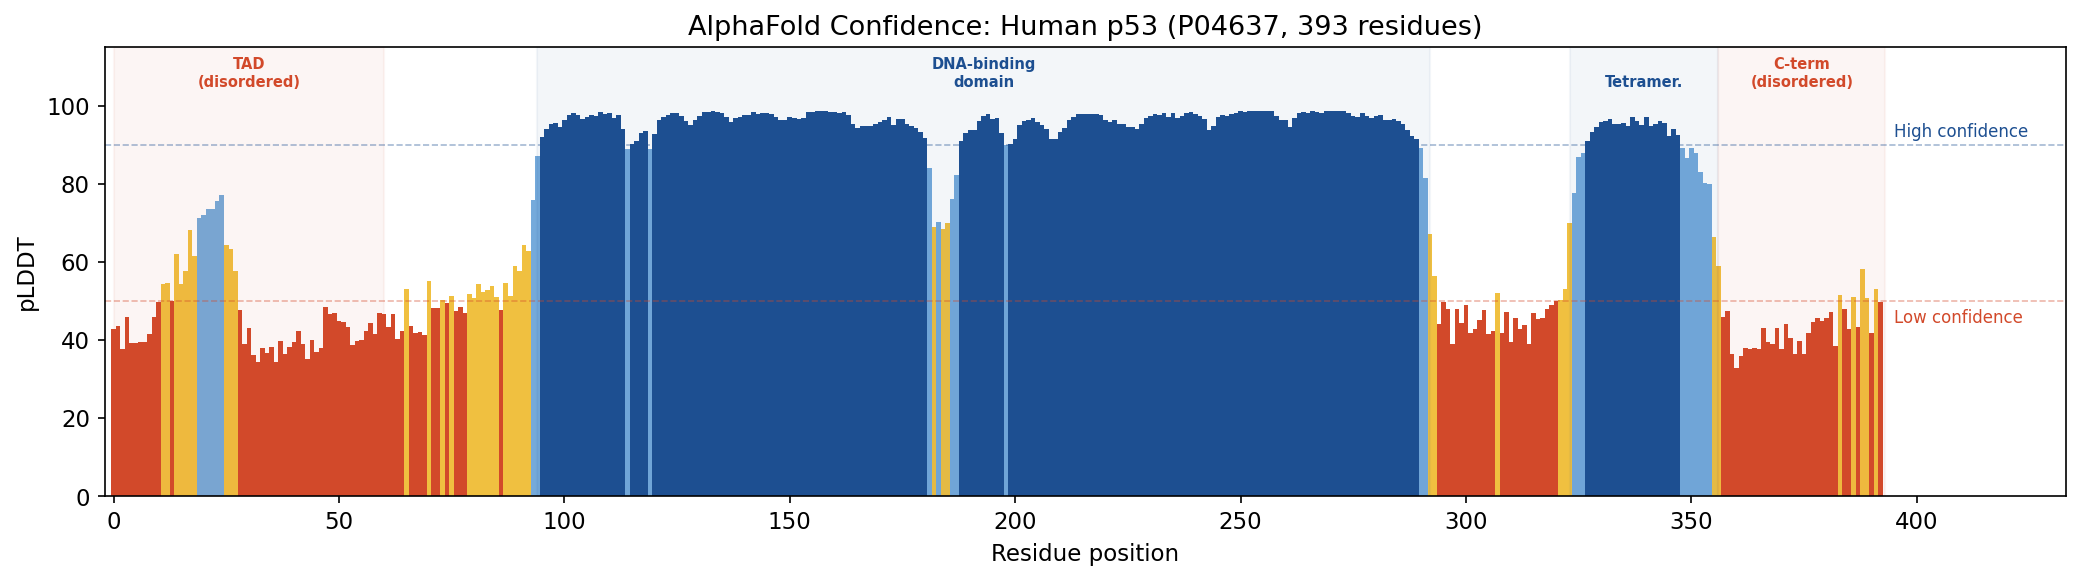

Saved: figures/fig3_alphafold_plddt.png


In [7]:
# ==============================================================================
# Figure 3: AlphaFold pLDDT visualization
# ==============================================================================
uniprot_id = "P04637"
plddt = None
try:
    print(f"Fetching AlphaFold prediction for {uniprot_id} (p53)...")
    resp = requests.get(f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}", timeout=15)
    if resp.status_code == 200:
        af_data = resp.json()
        if isinstance(af_data, list): af_data = af_data[0]
        pdb_url = af_data.get('pdbUrl', af_data.get('cifUrl', ''))
        if pdb_url:
            pdb_text = requests.get(pdb_url, timeout=30).text
            plddt_values = []
            for line in pdb_text.split("\n"):
                if line.startswith("ATOM") and line[12:16].strip() == "CA":
                    plddt_values.append(float(line[60:66].strip()))
            if plddt_values:
                plddt = np.array(plddt_values)
                print(f"  Got {len(plddt)} residues, pLDDT range: {plddt.min():.0f}-{plddt.max():.0f}")
except Exception as e:
    print(f"  AFDB fetch failed: {e}")

if plddt is None:
    print("  Using realistic simulated pLDDT for p53 (AFDB unreachable)")
    np.random.seed(42)
    plddt = np.concatenate([
        np.clip(np.random.normal(35, 8, 60), 0, 100),
        np.clip(np.random.normal(55, 10, 34), 0, 100),
        np.clip(np.random.normal(88, 5, 198), 0, 100),
        np.clip(np.random.normal(60, 12, 31), 0, 100),
        np.clip(np.random.normal(85, 6, 33), 0, 100),
        np.clip(np.random.normal(30, 8, 37), 0, 100),
    ])

fig, ax = plt.subplots(figsize=(14, 4))
colors = np.where(plddt > 90, COLUMBIA,
          np.where(plddt > 70, COLUMBIA_LIGHT,
          np.where(plddt > 50, '#F0C040', ACCENT)))
ax.bar(range(len(plddt)), plddt, color=colors, width=1.0, edgecolor='none')

for start, end, label, color in [(0,60,'TAD\n(disordered)',ACCENT),
                                   (94,292,'DNA-binding\ndomain',COLUMBIA),
                                   (323,356,'Tetramer.',COLUMBIA),
                                   (356,393,'C-term\n(disordered)',ACCENT)]:
    ax.annotate(label, ((start+end)/2, 105), fontsize=7, ha='center', color=color, fontweight='bold')
    ax.axvspan(start, end, alpha=0.05, color=color)

ax.axhline(90, color=COLUMBIA, linestyle='--', alpha=0.4, linewidth=0.8)
ax.axhline(50, color=ACCENT, linestyle='--', alpha=0.4, linewidth=0.8)
ax.text(len(plddt)+2, 91, 'High confidence', fontsize=8, color=COLUMBIA, va='bottom')
ax.text(len(plddt)+2, 48, 'Low confidence', fontsize=8, color=ACCENT, va='top')
ax.set_xlabel('Residue position'); ax.set_ylabel('pLDDT')
ax.set_title(f'AlphaFold Confidence: Human p53 ({uniprot_id}, {len(plddt)} residues)')
ax.set_xlim(-2, len(plddt)+40); ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig('figures/fig3_alphafold_plddt.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figures/fig3_alphafold_plddt.png")

---
## Figure 4: DNA FM Evaluation Gap

**LECTURE FIGURE** (slide: "The Controversy")

**This figure uses simulated data** because Enformer (200M+ params) cannot run in Colab.
The simulation is calibrated to published benchmark numbers from Sasse et al. (2023):

| Task | Published r | Source |
|------|-------------|--------|
| Reference expression | ~0.85 | Sasse et al. 2023; Huang et al. 2023 |
| Variant effect (model) | ~0.1-0.2 | Sasse et al. 2023; Huang et al. 2023 |
| Variant effect (baseline) | ~0.1-0.15 | Sasse et al. 2023; Huang et al. 2023 |

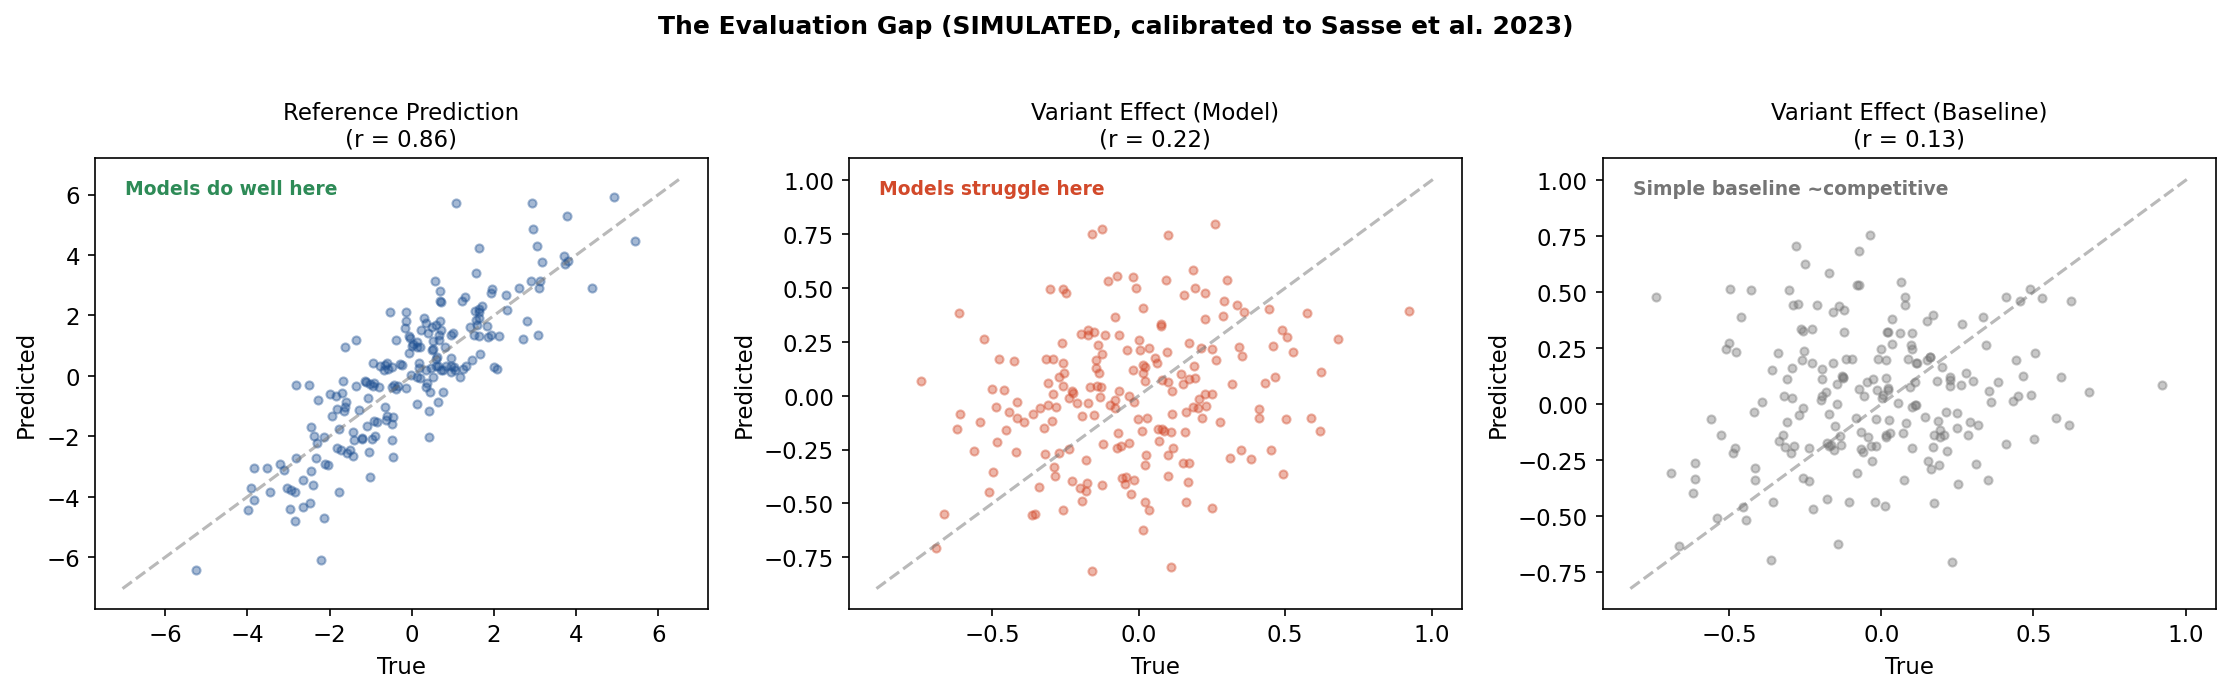

Saved: figures/fig4_dna_fm_evaluation.png

Published benchmarks (Sasse et al. 2023):
  Reference expression: r ~ 0.85 (simulated: 0.86)
  Variant effects (Enformer): r ~ 0.1-0.2 (simulated: 0.22)
  Variant effects (baseline): r ~ 0.1-0.15 (simulated: 0.13)


In [8]:
# ==============================================================================
# Figure 4: DNA FM evaluation gap (SIMULATED, calibrated to Sasse et al. 2023)
# ==============================================================================
np.random.seed(42)
n = 200

# Calibrated to published ranges
true_expr = np.random.randn(n) * 2
pred_expr = true_expr + np.random.randn(n) * 1.2    # target r ~ 0.85

true_delta = np.random.randn(n) * 0.3
pred_delta = true_delta * 0.12 + np.random.randn(n) * 0.30   # target r ~ 0.15
baseline_delta = true_delta * 0.10 + np.random.randn(n) * 0.30  # target r ~ 0.12

r_ref = np.corrcoef(true_expr, pred_expr)[0,1]
r_var = np.corrcoef(true_delta, pred_delta)[0,1]
r_base = np.corrcoef(true_delta, baseline_delta)[0,1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
configs = [
    (true_expr, pred_expr, r_ref, 'Reference Prediction', COLUMBIA, 'Models do well here'),
    (true_delta, pred_delta, r_var, 'Variant Effect (Model)', ACCENT, 'Models struggle here'),
    (true_delta, baseline_delta, r_base, 'Variant Effect (Baseline)', GRAY, 'Simple baseline ~competitive'),
]
for ax, (xd, yd, r, title, col, note) in zip(axes, configs):
    ax.scatter(xd, yd, alpha=0.4, s=15, color=col)
    lims = [min(ax.get_xlim()[0],ax.get_ylim()[0]), max(ax.get_xlim()[1],ax.get_ylim()[1])]
    ax.plot(lims, lims, '--', color=GRAY, alpha=0.5)
    ax.set_xlabel('True'); ax.set_ylabel('Predicted')
    ax.set_title(f'{title}\n(r = {r:.2f})', fontsize=11)
    note_col = GREEN if 'well' in note else (ACCENT if 'struggle' in note else GRAY)
    ax.text(0.05, 0.92, note, transform=ax.transAxes, fontsize=9, color=note_col, fontweight='bold')

plt.suptitle('The Evaluation Gap (SIMULATED, calibrated to Sasse et al. 2023)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig4_dna_fm_evaluation.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: figures/fig4_dna_fm_evaluation.png")
print(f"\nPublished benchmarks (Sasse et al. 2023):")
print(f"  Reference expression: r ~ 0.85 (simulated: {r_ref:.2f})")
print(f"  Variant effects (Enformer): r ~ 0.1-0.2 (simulated: {r_var:.2f})")
print(f"  Variant effects (baseline): r ~ 0.1-0.15 (simulated: {r_base:.2f})")

---
## Discussion Questions

1. **ESM contacts from attention:** The 35M model shows initial contact recovery but is far from published ESM-650M results. Is contact prediction a capability that emerges at scale, or present but weak at all scales?

2. **Variant effect prediction:** Some ClinVar pathogenic mutations score near zero. Why might a disease-causing mutation look "allowed" to a language model? (Hint: gain-of-function, tissue specificity.)

3. **AlphaFold confidence:** p53's TAD is low-confidence. Is this a failure or correct identification of disorder?

4. **Genomic model evaluation:** Sasse and Huang et al. show r~0.15 for variant effects vs r~0.85 for reference expression. Is this fundamental or solvable? How does L25's "DNA in context" relate?

5. **2D vs. 3D molecular models:** In Lab 12, you trained GCN and GIN on BBBP using 2D molecular graphs. L26 showed that chirality (thalidomide) means 3D shape determines biological activity, but fingerprints can't distinguish enantiomers. For which tasks would Lab 12's 2D GNNs be sufficient, and for which would you need a 3D-aware model?

6. **Classical baselines:** L26 showed SIFT and fingerprint-QSAR are competitive. When should you prefer ESM over SIFT, or a 3D molecular model over fingerprints?